In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q gdown

import gdown
import os
import zipfile
import shutil
import random

file_id = "1PwZXse2huPI_weaKCSq21Olu2ButPFyM"
output = "/kaggle/working/data.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

print("Download completed")



extract_path = "/kaggle/working/data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")


paths_to_delete = [
    "/kaggle/working/data/.config",
    "/kaggle/working/data/.ipynb_checkpoints",
    "/kaggle/working/data/all_folders.zip",
    "/kaggle/working/data/drive",
    "/kaggle/working/.virtual_documents"
]

for path in paths_to_delete:
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted folder: {path}")
    elif os.path.isfile(path):
        os.remove(path)
        print(f"Deleted file: {path}")
    else:
        print(f"Path not found (skipped): {path}")


def split_classes_train_val(
    data_dir,
    train_ratio=0.8,
    seed=42,
    extensions=None
):
    """
    Splits each class folder into train/ and validation/ subfolders.

    Structure BEFORE:
    data/
        class1/
            img1.jpg
            img2.jpg
        class2/
            img1.jpg
            img2.jpg

    Structure AFTER:
    data/
        class1/
            train/
            validation/
        class2/
            train/
            validation/
    """

    random.seed(seed)

    classes = [
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ]

    for cls in classes:
        class_path = os.path.join(data_dir, cls)

        files = [
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ]

        if extensions:
            files = [f for f in files if f.lower().endswith(extensions)]

        if len(files) == 0:
            continue

        random.shuffle(files)

        split_idx = int(len(files) * train_ratio)
        train_files = files[:split_idx]
        val_files = files[split_idx:]

        train_dir = os.path.join(class_path, "train")
        val_dir = os.path.join(class_path, "validation")

        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)

        for f in train_files:
            shutil.move(
                os.path.join(class_path, f),
                os.path.join(train_dir, f)
            )

        for f in val_files:
            shutil.move(
                os.path.join(class_path, f),
                os.path.join(val_dir, f)
            )

        print(
            f"{cls}: "
            f"{len(train_files)} train, "
            f"{len(val_files)} validation"
        )
data_dir = "/kaggle/working/data"

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp",
    ".ppm", ".pgm", ".pbm"
)

split_classes_train_val(
    data_dir=data_dir,
    train_ratio=0.8,
    extensions=IMAGE_EXTENSIONS
)



def keep_only_train_val(data_dir):
    allowed = {"train", "validation"}

    classes = [
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ]

    for cls in classes:
        class_path = os.path.join(data_dir, cls)

        for item in os.listdir(class_path):
            item_path = os.path.join(class_path, item)

            if os.path.isdir(item_path) and item not in allowed:
                shutil.rmtree(item_path)
                print(f"Deleted: {item_path}")

data_dir = "/kaggle/working/data"
keep_only_train_val(data_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1PwZXse2huPI_weaKCSq21Olu2ButPFyM
From (redirected): https://drive.google.com/uc?id=1PwZXse2huPI_weaKCSq21Olu2ButPFyM&confirm=t&uuid=04ab8b47-8cc4-469e-ba98-6703ff603ed8
To: /kaggle/working/data.zip
100%|██████████| 993M/993M [00:14<00:00, 66.3MB/s]


Download completed
Extraction completed
Deleted folder: /kaggle/working/data/.config
Deleted folder: /kaggle/working/data/.ipynb_checkpoints
Deleted file: /kaggle/working/data/all_folders.zip
Deleted folder: /kaggle/working/data/drive
Path not found (skipped): /kaggle/working/.virtual_documents
cleaver_dataset: 800 train, 200 validation
Chiffonier_dataset: 800 train, 200 validation
Vacuum_cleaner_dataset: 800 train, 200 validation
Pitcher_dataset: 800 train, 200 validation
Toaster_dataset: 800 train, 200 validation
Bed_dataset: 755 train, 189 validation
refrigerator_dataset: 800 train, 200 validation
table dataset: 800 train, 200 validation
Mixing bowl_dataset: 800 train, 200 validation
Hand Blower_dataset: 800 train, 200 validation
Waffle iron_dataset: 800 train, 200 validation
Teapot_dataset: 800 train, 200 validation
Crock pot_dataset: 800 train, 200 validation
Dishwasher_dataset: 800 train, 200 validation
wardrobe_dataset: 800 train, 200 validation
coffe maker_dataset: 800 train, 2

In [3]:
# 2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# # 3
# import os
# from torch.utils.data import Dataset, DataLoader
# from PIL import Image

# # 1. Define a Custom Dataset to handle your specific folder structure
# class FurnitureDataset(Dataset):
#     def __init__(self, root_dir, split='train', transform=None):
#         self.root_dir = root_dir
#         self.split = split
#         self.transform = transform
#         self.image_paths = []
#         self.labels = []
        
#         # Get class names from the folder names in data/
#         self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
#         self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

#         # Walk through each class folder and pick files from the correct split (train or validation)
#         for cls_name in self.classes:
#             split_dir = os.path.join(root_dir, cls_name, self.split)
#             if os.path.exists(split_dir):
#                 for img_name in os.listdir(split_dir):
#                     if img_name.lower().endswith(IMAGE_EXTENSIONS):
#                         self.image_paths.append(os.path.join(split_dir, img_name))
#                         self.labels.append(self.class_to_idx[cls_name])

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert('RGB')
#         label = self.labels[idx]
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# # 2. Initialize the Datasets using the data_dir from Cell 1
# # Note: Ensure IMAGE_EXTENSIONS and data_dir are defined (they are in your Cell 1)
# train_dataset = FurnitureDataset(data_dir, split='train', transform=data_transforms['train'])
# val_dataset = FurnitureDataset(data_dir, split='validation', transform=data_transforms['validation'])

# # 3. Create DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# print(f"Found {len(train_dataset)} training images and {len(val_dataset)} validation images.")
# print(f"Classes identified: {train_dataset.classes}")
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# 1. Define Transformations (This was the missing piece!)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Define Custom Dataset Class
class FurnitureDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Get class names from the folder names in data/
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            split_dir = os.path.join(root_dir, cls_name, self.split)
            if os.path.exists(split_dir):
                for img_name in os.listdir(split_dir):
                    # Using the IMAGE_EXTENSIONS defined in your Cell 1
                    if img_name.lower().endswith(IMAGE_EXTENSIONS):
                        self.image_paths.append(os.path.join(split_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# 3. Initialize Datasets and Loaders
# data_dir is defined in your Cell 1
train_dataset = FurnitureDataset(data_dir, split='train', transform=data_transforms['train'])
val_dataset = FurnitureDataset(data_dir, split='validation', transform=data_transforms['validation'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Success! Found {len(train_dataset)} training images.")
print(f"Classes: {train_dataset.classes}")

Success! Found 19955 training images.
Classes: ['Bed_dataset', 'Chiffonier_dataset', 'Crock pot_dataset', 'Dishwasher_dataset', 'Electric_fan_dataset', 'Frying pan_dataset', 'Hand Blower_dataset', 'Mixing bowl_dataset', 'Pitcher_dataset', 'Salt Shaker_dataset', 'Sofas_dataset', 'Teapot_dataset', 'Television_dataset', 'Toaster_dataset', 'Vacuum_cleaner_dataset', 'Waffle iron_dataset', 'carpet_dataset', 'chair_dataset', 'cleaver_dataset', 'coffe maker_dataset', 'microwave_dataset', 'refrigerator_dataset', 'stove_dataset', 'table dataset', 'wardrobe_dataset']


In [5]:
# 4
# Load pre-trained ResNet18
model = models.resnet101(pretrained=True)

# Freeze early layers (optional, but recommended for small datasets)
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer
num_ftrs = model.fc.in_features
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 187MB/s]


In [6]:
import time
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

class EarlyStopping:
    def __init__(self, patience=5, delta=0, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

def train_model(model, criterion, optimizer, scheduler, num_epochs=35, patience=5):
    since = time.time()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize Early Stopping
    early_stopping = EarlyStopping(patience=patience, path='best_model.pth')
    
    history = {
        'train_loss': [], 'train_acc': [], 
        'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': []
    }

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 15)

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Metrics Calculations
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            
            # Calculate Precision, Recall, and F1 (Weighted averages handle class imbalance)
            precision, recall, f1, _ = precision_recall_fscore_support(
                all_labels, all_preds, average='weighted', zero_division=0
            )

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_precision'].append(precision)
                history['val_recall'].append(recall)
                history['val_f1'].append(f1)
                
                print(f'Val   Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                print(f'Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')

                # Update Scheduler and Early Stopping based on validation loss
                scheduler.step(epoch_loss)
                early_stopping(epoch_loss, model)

        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    # Load best model weights before returning
    try:
        model.load_state_dict(torch.load('best_model.pth'))
    except FileNotFoundError:
        print("Note: No checkpoint file found, returning last model state.")
        
    return model, history

# --- Execution ---
# Ensure 'scheduler' is defined (e.g., torch.optim.lr_scheduler.ReduceLROnPlateau)
model_ft, history = train_model(model, criterion, optimizer, scheduler, num_epochs=30, patience=5)


Epoch 1/30
---------------
Train Loss: 0.5626 Acc: 0.8544
Val   Loss: 0.2711 Acc: 0.9192
Precision: 0.9244 | Recall: 0.9192 | F1: 0.9197

Epoch 2/30
---------------
Train Loss: 0.2950 Acc: 0.9118
Val   Loss: 0.2618 Acc: 0.9204
Precision: 0.9279 | Recall: 0.9204 | F1: 0.9216

Epoch 3/30
---------------
Train Loss: 0.2643 Acc: 0.9187
Val   Loss: 0.2463 Acc: 0.9284
Precision: 0.9316 | Recall: 0.9284 | F1: 0.9286

Epoch 4/30
---------------
Train Loss: 0.2362 Acc: 0.9266
Val   Loss: 0.2284 Acc: 0.9296
Precision: 0.9312 | Recall: 0.9296 | F1: 0.9295

Epoch 5/30
---------------
Train Loss: 0.2413 Acc: 0.9257
Val   Loss: 0.2347 Acc: 0.9278
Precision: 0.9302 | Recall: 0.9278 | F1: 0.9277
EarlyStopping counter: 1 out of 5

Epoch 6/30
---------------
Train Loss: 0.2253 Acc: 0.9286
Val   Loss: 0.2562 Acc: 0.9248
Precision: 0.9293 | Recall: 0.9248 | F1: 0.9250
EarlyStopping counter: 2 out of 5

Epoch 7/30
---------------
Train Loss: 0.2120 Acc: 0.9326
Val   Loss: 0.2329 Acc: 0.9341
Precision: 0.9

In [7]:
# 6
torch.save(model, 'furniture_resnet101_model_full.pth')
torch.save(model_ft.state_dict(), 'furniture_resnet101_model.pth')
print("Model saved!")

Model saved!


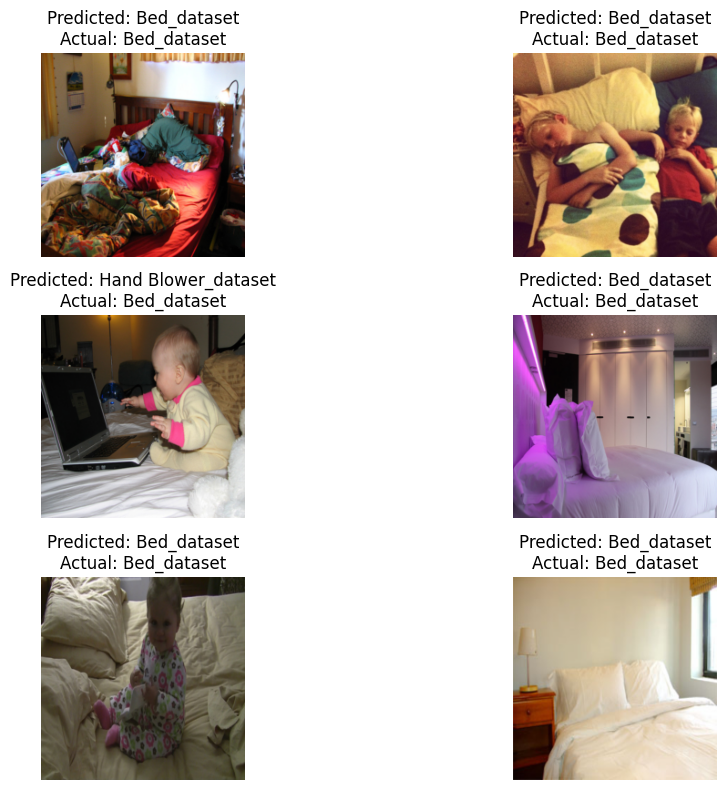

In [8]:
# 7
import numpy as np

def visualize_model_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                
                # Rescale image for viewing (un-normalize)
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                ax.set_title(f'Predicted: {train_dataset.classes[preds[j]]}\nActual: {train_dataset.classes[labels[j]]}')
                plt.imshow(img)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Run the visualization
visualize_model_predictions(model_ft)
plt.tight_layout()
plt.show()